# All units are in MW

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [2]:

import glob
# Get a list of all CSV files in the 'data' directory
csv_files = glob.glob('demand data/*.csv')
# Create an empty list to store the dataframes
dfs = []
# Loop through each CSV file, read it into a dataframe, and append it to the list
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)
# Concatenate all dataframes in the list into a single dataframe
merged_df = pd.concat(dfs, ignore_index=True)
# Save the merged dataframe to a new CSV file
merged_df.to_csv('merged_demand_data.csv', index=False)


In [3]:
merged_df[merged_df['SETTLEMENT_DATE'].isna()]

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,SCOTTISH_TRANSFER


In [4]:
merged_df1 = merged_df.drop(columns=['NON_BM_STOR',	'SCOTTISH_TRANSFER', 'IFA_FLOW','IFA2_FLOW', 'BRITNED_FLOW',	'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW', 'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW'])
print(merged_df1.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0     01-JAN-2010                  1  36453  37593                 32391   
1     01-JAN-2010                  2  36680  37739                 32590   
2     01-JAN-2010                  3  36343  37467                 32291   
3     01-JAN-2010                  4  35362  36489                 31366   
4     01-JAN-2010                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  PUMP_STORAGE_PUMPING  
0                          0                        0                   306  
1                          0                        0   

In [5]:

merged_df1['SETTLEMENT_DATE'] = pd.to_datetime(merged_df1['SETTLEMENT_DATE'], format= 'mixed', errors='coerce')
#merged_df1['Year'] = merged_df1['SETTLEMENT_DATE'].dt.year
#print(f"dtype of column: {merged_df1.dtypes}")

In [6]:
#merged_df1['SETTLEMENT_DATE'] = pd.to_datetime(merged_df1['SETTLEMENT_DATE'], format='%Y-%m-%d')
#merged_df1['SETTLEMENT_DATE'] = merged_df1['SETTLEMENT_DATE'].dt.strftime('%Y-%m-%d')

In [7]:
print(merged_df1.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  PUMP_STORAGE_PUMPING  
0                          0                        0                   306  
1                          0                        0   

In [8]:
print(merged_df1.tail())

       SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
281899      2026-01-29                 44  33935  35418                 31482   
281900      2026-01-29                 45  31873  33079                 29588   
281901      2026-01-29                 46  30217  31208                 28086   
281902      2026-01-29                 47  28193  29157                 26243   
281903      2026-01-29                 48  26709  27676                 24927   

        EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
281899                      3303                    6606   
281900                      3274                    6606   
281901                      3244                    6606   
281902                      3289                    6606   
281903                      3334                    6606   

        EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  \
281899                          0                    21504   
281900                      

In [9]:
merged_df1['FULL_TIMESTAMP'] = merged_df1['SETTLEMENT_DATE'] + (merged_df1['SETTLEMENT_PERIOD'] - 1) * pd.Timedelta(minutes=30)
print(merged_df1.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  PUMP_STORAGE_PUMPING  \
0                          0                        0                   306   
1                          0                        0 

In [10]:
merged_df1['HALF_HOURLY'] = merged_df1['FULL_TIMESTAMP'].dt.time
merged_df1['DAY_OF_WEEK'] = merged_df1['FULL_TIMESTAMP'].dt.dayofweek
merged_df1['MONTH'] = merged_df1['FULL_TIMESTAMP'].dt.month
print(merged_df1.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  PUMP_STORAGE_PUMPING  \
0                          0                        0                   306   
1                          0                        0 

In [11]:
# regional spllit from ND
#region_shares = {
#    "London": 0.14,
#    "South_East": 0.15,
#    "South_West": 0.11,
#    "Midlands": 0.19,
#    "North_West": 0.13,
#    "North_East": 0.125,
#    "South_Scotland": 0.125,
#    "North_Scotland": 0.03
#}
#for region, share in region_shares.items():
#    merged_df1[region] = merged_df1['ND'] * share

In [12]:
#merged_df1["regional_sum"] = merged_df1[["London", "South_East", "South_West", "Midlands", "North_West", "North_East", "South_Scotland", "North_Scotland"]].sum(axis=1)
print(merged_df1.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  PUMP_STORAGE_PUMPING  \
0                          0                        0                   306   
1                          0                        0 

merged_df1[["ND", "regional_sum"]].head()

In [13]:
# Quick analysis example
weekly_avg = merged_df1.groupby('DAY_OF_WEEK')['ENGLAND_WALES_DEMAND'].mean()
print(weekly_avg)

DAY_OF_WEEK
0    28495.451866
1    29125.661278
2    29170.852180
3    29090.147919
4    28507.307112
5    25653.430969
6    25031.034220
Name: ENGLAND_WALES_DEMAND, dtype: float64


In [14]:
# This saves the file to your current working directory
#merged_df1.to_csv('merged_data.csv', index=False)

In [15]:
y = merged_df1[['ND']]

In [16]:
features = ['SETTLEMENT_PERIOD', 'DAY_OF_WEEK', 'MONTH', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION', 'PUMP_STORAGE_PUMPING', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION']
x = merged_df1[features]

In [17]:
# splitting the data into training and testing sets based on date
train = merged_df1[merged_df1['SETTLEMENT_DATE'] < '2023-01-01']
test = merged_df1[merged_df1['SETTLEMENT_DATE'] >= '2023-01-01']
X_train = train[features]
y_train = train[['ND']]
X_test = test[features]
y_test = test[['ND']]

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


c:\Users\ahiar\anaconda3\envs\smart_home\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [19]:
pred_merged_df1 = pd.DataFrame(y_pred, columns=y_train.columns)

In [20]:
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')

Mean Absolute Error: 2729.540201384553


In [21]:
#predict test set
y_pred = model.predict(X_test)
#calculate MAE for each region
mae_per_region = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
# Create a readable summary
comparison_merged_df1 = pd.DataFrame({
    'Region': ['ND'],
    'MAE': mae_per_region,
    'Average_Actual_Value': y_test.mean().values
})

# Add a percentage error for context
comparison_merged_df1['Error_Pct'] = (comparison_merged_df1['MAE'] / comparison_merged_df1['Average_Actual_Value']) * 100
print(comparison_merged_df1)
#for region in y_train.columns:
    #region_mae = mean_absolute_error(y_test[region], y_pred[:, y_train.columns.get_loc(region)])
    #print(f'Mean Absolute Error for {region}: {region_mae}')

  Region          MAE  Average_Actual_Value  Error_Pct
0     ND  2729.540201          26341.782204  10.362018


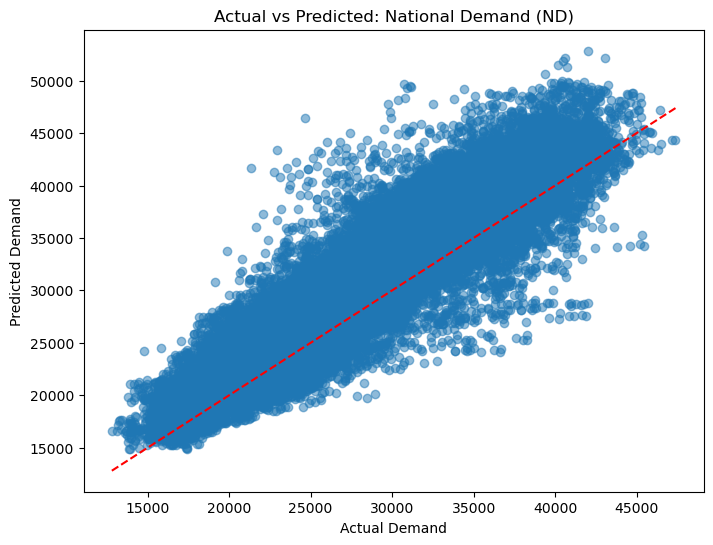

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title('Actual vs Predicted: National Demand (ND)')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')

plt.show()

In [24]:
# Check if regions are identical
correlation_matrix = merged_df1[['ND']].corr()
print(correlation_matrix)

     ND
ND  1.0


In [25]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f}")

MAE: 2729.54


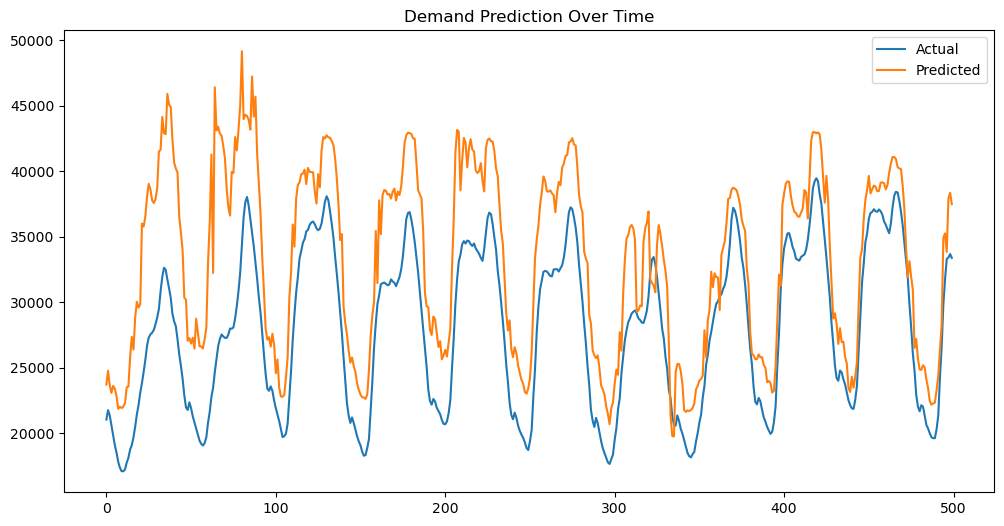

In [26]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:500], label='Actual')
plt.plot(y_pred[:500], label='Predicted')
plt.legend()
plt.title("Demand Prediction Over Time")
plt.show()

In [28]:
y_pred

array([23715.00833333, 24759.65134615, 23652.56833333, ...,
       30833.7       , 28067.52973481, 26530.63666667], shape=(54000,))

In [29]:
results = test.copy()
results["Predicted_ND"] = y_pred

In [30]:
window_size = 4  # 2 hours

results["rolling_mean"] = results["Predicted_ND"].rolling(window=window_size).mean()

In [31]:
best_slot = results["rolling_mean"].idxmin()
best_time = results.loc[best_slot, "FULL_TIMESTAMP"]

print("Best time to run appliance:", best_time)

Best time to run appliance: 2025-05-25 05:30:00


In [32]:
appliances = {
    "washing_machine": 4,  # 2 hours
    "dishwasher": 3,       # 1.5 hours
    "EV_charger": 6        # 3 hours
}

In [33]:
def schedule_appliance(results, duration):
    rolling = results["Predicted_ND"].rolling(window=duration).mean()
    best_idx = rolling.idxmin()
    return results.loc[best_idx, "FULL_TIMESTAMP"]

In [34]:
for appliance, duration in appliances.items():
    time = schedule_appliance(results, duration)
    print(f"{appliance} → {time}")

washing_machine → 2025-05-25 05:30:00
dishwasher → 2025-05-25 05:30:00
EV_charger → 2025-05-25 06:00:00


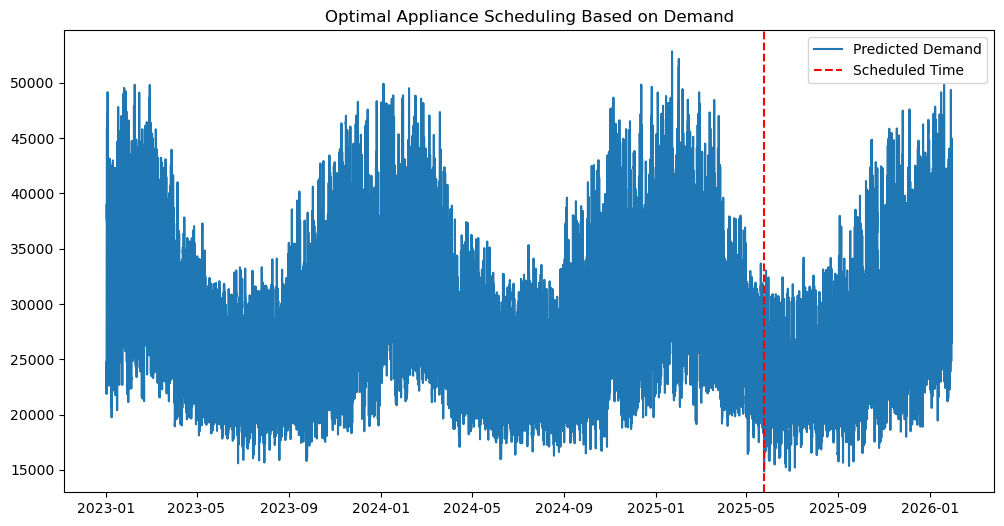

In [35]:
plt.figure(figsize=(12,6))
plt.plot(results["FULL_TIMESTAMP"], results["Predicted_ND"], label="Predicted Demand")

plt.axvline(best_time, color='r', linestyle='--', label='Scheduled Time')

plt.legend()
plt.title("Optimal Appliance Scheduling Based on Demand")
plt.show()